In [52]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
# plt.style.use('max_style.mplstyle')

from numba.experimental import jitclass
import numba as nb
from scipy.interpolate import interp1d

from tqdm import tqdm
from time import time
from spl import spline
from scipy.optimize import minimize

from scipy.fftpack import fft, ifft
from scipy.interpolate import interp1d
import seaborn as sns
from sklearn.metrics import mean_squared_error
import matplotlib.patches as patches
import matplotlib.colors as mcolors 

%matplotlib inline

# <center>Define Verlet and System Base Class</center><a id="first-bullet"></a>

In [53]:
class verlet():
    def getAcc(self, positions, _):
        """
        simple harmonic oscillator.
        This is for testing purposes. The user should 
        overload this function in order to implement the system
        that should be simulated. 
        (like multiple ions interact with eachother)
        """
        
        return -positions
    
    def integrate(self, endtime, dt):
        """
        calculate the trajectory for N Ions in M Dimensions.
        implemented shortened velocity verlet from:
        https://en.wikipedia.org/wiki/Verlet_integration
        assumes, that acceleration only depends on position.

        Parameters
        ----------
        self.getAcc : function(array) : array
            verlet integrates only, so acceleration function
            needs to implemented by the user!
            see getAcc docstring

        endtime : float
            Seconds on where to end simulation.

        dt : float
            step size between each evaluation step in Seconds.
            With our setup of iontraps less or equal to
            5e-9 is recommended! (redtrap)

        Returns
        -------
        tpoints : np.array
            points of all evaluated timesteps

        ppoints : np.array
            ppoints[:, 0, 0, 0]
                    |  |  |  |
                    |  |  |  > dimension x (or general 1st dim)
                    |  |  > 0 is position, 
                    |  |    1 velocity, 2 acceleration
                    |  > choose ion #0
                    > all timesteps
        """

        n = int(endtime / dt)
        shape = (n,) + self.ions.shape
        tpoints = np.linspace(0, endtime, n)
        ppoints = np.empty(shape, dtype=np.float64)

        ppoints[0] = self.ions

        # iterate through all timepoints, see wiki link in docstring
        for k in range(len(tpoints)-1):
            ppoints[k+1, :, 0] = ppoints[k, :, 0] + ppoints[k, :, 1] * dt + 0.5 * ppoints[k, :, 2] * dt**2
            ppoints[k+1, :, 2] = self.getAcc(ppoints[k+1, :, 0, 0], k+1)
            ppoints[k+1, :, 1] = ppoints[k, :, 1] + 0.5 * (ppoints[k, :, 2] + ppoints[k+1, :, 2]) * dt

        return tpoints, ppoints

In [54]:
spec1 = [('ions', nb.float64[:, :, :]),
        ('trap', nb.float64[:, :, :]),
        ('splcoeff', nb.float64[:, :, :]),
        ('volt', nb.float64[:, :]),
        ('qdm', nb.float64),]

@jitclass(spec1)
class red_system(verlet, spline):
    def __init__(self, trap):
        
        self.splcoeff = np.empty(trap.shape)
        
        for i in range(len(trap)):
            self.splcoeff[i, 0] = self.splrep(trap[i, 0], trap[i, 1])
            self.splcoeff[i, 1] = self.splrep(trap[i, 0], trap[i, 2])
        
        self.trap = trap
        
        q = 1.60217662e-19
        m = 1.66054e-27*39.96259
        self.qdm = q/m
        
    def propagate(self, ramp, endtime, dt):
        n = int(endtime / dt)
        tpoints = np.linspace(0, endtime, n)
    
        self.volt = np.zeros((len(ramp)-1, n))
        for i in range(len(ramp)-1):
            self.volt[i] = np.interp(tpoints, ramp[0], ramp[i+1])

        return self.integrate(endtime, dt)
        
        
    def setIons(self, positions):
        """
        set the initial positions of the ions.
        
        Parameters
        ----------
        posistions : np.array
            has size (#numberOfIons, positions).
            For one dim (x, 3, 1), for 3 dim (x, 3, 3)
            with position, velocity, acceleration
        """
        self.ions = positions
    
    def getAcc(self, position, k):
        acc = np.zeros(position.shape)
        
        for i in range(len(self.trap)):
            acc += self.volt[i, k] * self.splev(position, self.trap[i, 0], self.trap[i, 2], self.splcoeff[i, 1])
            
        return acc * self.qdm
    
    def getPot(self, position, k):
        # TODO find out what k is
        pot = np.zeros(position.shape)
        
        for i in range(len(self.trap)):
            pot += self.volt[i, k] * self.splev(position, self.trap[i, 0], self.trap[i, 1], self.splcoeff[i, 0])
        return pot

### load trap geometry <a id="load-trap-geometry"></a>

In [55]:
trap = np.load('redtrap.npy')
trap[:, 0] *= 1e-3
trap[:, 1:] *= 2
print(trap.shape[0])

16


## Plot the Poential with 1V applied
(multiply with any value; potential scales linearly with applied voltage)


### Task:
- read the paper from Ferdinand and calculate the trap frequency with the potential below

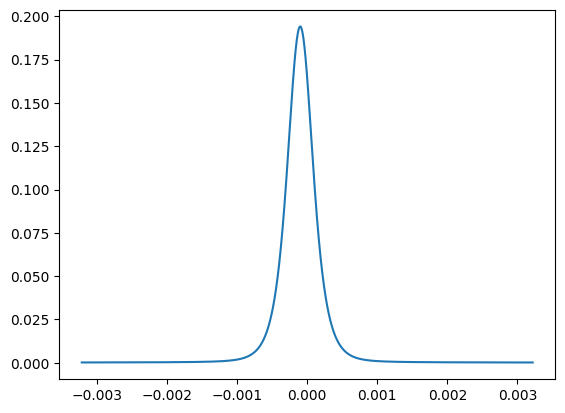

In [56]:
plt.plot(trap[15, 0], trap[15,1])
plt.show()

## Find out whether the middle of segment 15 is nummerically also the minima of the potential

x should be:

x: [-1.000e-04]

array([-0.10475576])

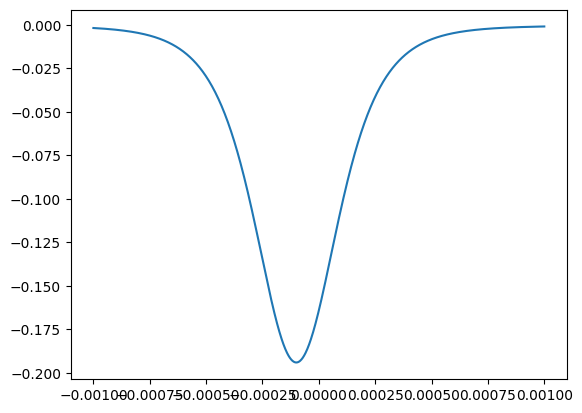

In [57]:
test = red_system(trap)  
test.setIons(np.array([[[-300.0e-6],[0],[0]],], dtype=np.float64))
voltage = np.zeros((16, 1))
voltage[15, 0] = -1
test.volt = voltage
#print(minimize(lambda t: test.getPot(np.array([t]), 0)[0], 300e-6))

x = np.linspace(-1e-3, 1e-3, 1000)
plt.plot(x, test.getPot(x, 0))
test.getPot(np.array([100e-6]), 0)

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -0.1941244313729034
        x: [-1.000e-04]
      nit: 4
      jac: [ 3.725e-09]
 hess_inv: [[ 1.499e-07]]
     nfev: 30
     njev: 15
index min 450
---------------
x_min: -9.909909909909921e-05
y_min: -0.1941217236569295


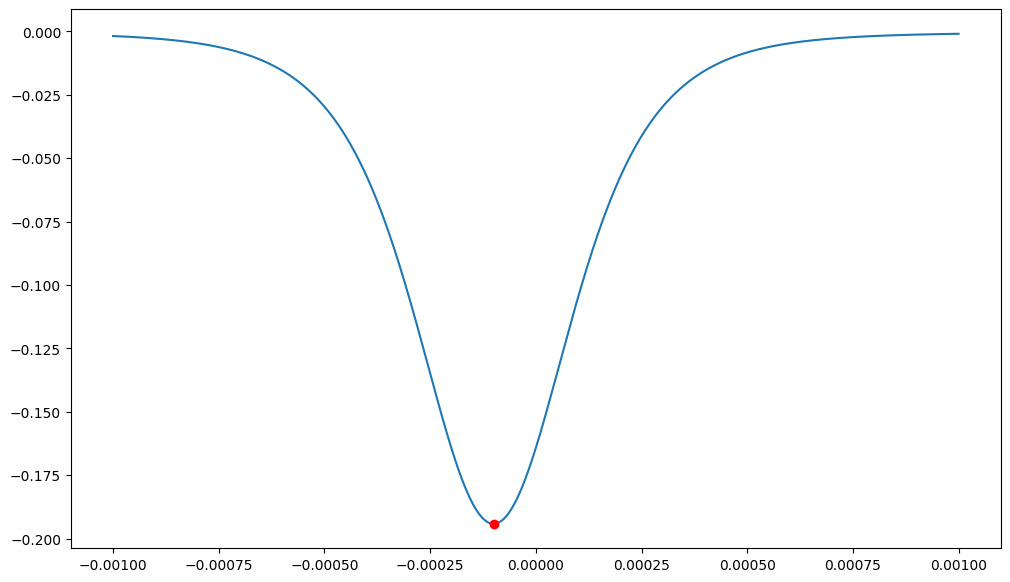

In [58]:
redtrap = red_system(trap)  
redtrap.setIons(np.array([[[-300.0e-6],[0],[0]],], dtype=np.float64))
voltage = np.zeros((16, 1))
voltage[15, 0] = -1
redtrap.volt = voltage
print(minimize(lambda t: redtrap.getPot(t, 0), 300e-6))

x = np.linspace(-1e-3, 1e-3, 1000)
redtrap.getPot(np.array([100e-6]), 0)

pot = redtrap.getPot(x, 0)         # potential array
idx_min = np.argmin(pot)           # index of minimum value
x_min = x[idx_min]                 # x-value at minimum
pot_min = pot[idx_min]              # minimum potential value

print(f'index min', idx_min)

print('---------------')
print("x_min:", x_min)
print("y_min:", pot_min)

plt.figure(figsize = (12, 7))
plt.plot(x, redtrap.getPot(x, 0))
plt.plot(x_min, pot_min, 'ro')
plt.show()

In [59]:
hbar = 6.62607015e-34 / 2 / np.pi
omega = 9.83511943e+06
hbar_omega = hbar * omega

# in eV
hbar_omega = hbar_omega / 1.602176634e-19

# Precompensation

## Algorithm

In [60]:
class FilterSimulation():

    def __init__(self):
        self.filter_constant = 0.0000175 # 17.5 hardware constraint on filter
        self.time_step =  0.00000038 # 0.38 DAQ time step constraint

    def filter(self):
        # load kernel:
        filter_kernel = np.load('filter_data.npy')
        samples = len(filter_kernel) # 300

        original_time = np.linspace(0, self.filter_constant, samples)

        target_samples = int(self.filter_constant / self.time_step) # 17.5 / 0.38 = 46
        compressed_time = np.linspace(0, self.filter_constant, target_samples) 

        # interpolate to get kernel to length 17.5 µs:
        interpolator = interp1d(original_time, filter_kernel, kind = 'cubic')
        compressed_kernel = interpolator(compressed_time)

        # get impulse response
        impulse_response = np.diff(compressed_kernel, prepend = 0)
        
        return impulse_response

    def pre_setup(self, waveform, waveform_size, wait_time):
        if waveform[0] != 0:
            waveform -= waveform[0]

        total_time = len(waveform) * self.time_step
        half_len = len(waveform) // 2

        # first and second halves of original
        rise = waveform[:half_len]
        fall = waveform[half_len:]

        # time arrays for rise and fall
        time_rise = np.linspace(0, total_time/2, half_len)
        time_fall = np.linspace(total_time/2 + wait_time, total_time + wait_time, half_len)

        # constant plateau section
        plateau_value = rise[-1]
        plateau_points = int(wait_time / self.time_step)
        time_plateau = np.linspace(time_rise[-1], time_rise[-1] + wait_time, plateau_points)
        plateau = np.full(plateau_points, plateau_value)

        # combine all
        time_array = np.concatenate([time_rise, time_plateau, time_fall])
        waveform_combined = np.concatenate([rise, plateau, fall])
        waveform_combined *= waveform_size # scale voltages as needed

        return time_array, waveform_combined

    def setup(self, time_array, waveform, compress, pad):
        compressed_time = time_array / compress
        dense_waveform = np.interp(time_array, compressed_time, waveform)

        mask = 0
        for i in range(0, len(compressed_time)):
            if time_array[i] <= compressed_time[-1]:
                mask += 1
            else:
                break
        masked_waveform = dense_waveform[:mask]

        original = np.pad(masked_waveform, pad_width = pad, mode = 'edge')
        time = np.arange(len(original)) * self.time_step

        return time, original

    def convolution(self, waveform):
        impulse_response = self.filter()
        filtered_waveform = np.convolve(waveform, impulse_response, mode = 'full')
        return filtered_waveform
    
    def interpolation(self, time, shift, filtered):
        interp_func = interp1d(shift, filtered, kind='cubic', bounds_error=False, fill_value="extrapolate")
        filtered_interp = interp_func(time)  # Now same length as time_original
        return filtered_interp
    
    def plotter(self, original, time, filtered, precompensated_unfiltered, precompensated_filtered):
        plt.figure()
        plt.plot(time, original, label = 'Original')
        plt.plot(time, filtered, label = 'Filtered')
        plt.plot(time, precompensated_unfiltered, label = 'Precompensated Unfiltered', linestyle = '--')
        plt.plot(time, precompensated_filtered, label = 'Precompensated Filtered', linestyle = '--')
        plt.title('Filter Waveforms')
        plt.xlabel('Time in µs')
        plt.ylabel('Voltage')
        plt.grid(True)
        plt.legend()
        plt.show()

    def scatter_plot(self, time, precompensated):
        plt.figure()
        plt.plot(time, precompensated, label = 'Full Plot', color = 'red')
        plt.scatter(time, precompensated, label = 'Scattered Plot', color = 'pink')
        plt.title('Precompensated Filtered Waveform')
        plt.xlabel('Time in µs')
        plt.ylabel('Voltage')
        plt.grid(True)
        plt.legend()
        plt.show()

    def precompensation(self, waveform, reg, pad):
        impulse_response = self.filter()
        total_length = max(len(impulse_response), len(waveform)) + 2 * pad

        left_pad = pad
        right_pad_ir = max(0, total_length - len(impulse_response) - pad)
        right_pad_waveform = max(0, total_length - len(waveform) - pad)

        ir_padded = np.pad(impulse_response, (left_pad, right_pad_ir), mode='constant')
        waveform_padded = np.pad(waveform, (left_pad, right_pad_waveform), mode='constant', constant_values = waveform[-1])

        G = fft(ir_padded)
        h_t = waveform_padded
        h_w = fft(h_t)

        G_magnitude = np.abs(G) # amplitude attenuation
        G_phase = np.angle(G) # phase shift

        # Tikhonov regularization: prevents division by zeros or near-zeros
        regularized_magnitude = G_magnitude / (G_magnitude**2 + reg)
        regularized_G = regularized_magnitude * np.exp(-1j * G_phase)

        f_w = h_w * regularized_G
        f_t = np.real(ifft(f_w))

        return f_t

    def trimming(self, original, precompensated, pad):
        for i in range(0, int(pad*0.5)):
            precompensated[i] = original[0]     
        for i in range(len(precompensated) - int(pad*0.5), len(precompensated)):
            precompensated[i] = original[-1]
        return precompensated
    

In [61]:
class Optimize():
    
    def __init__(self):
        self.padding_range = list(range(10, 31))
        self.reg_exponents = list(range(-6, 0))   
        self.reg_coeff = list(range(1, 8))
        self.compression_range = list(range(1, 12))
        
        self.lower_voltage_bound = -40
        self.upper_voltage_bound = 40
        self.time_step = 0.00000038

        self.alpha = 1.00 # <-- weight of max abs error
        self.beta = 0.01 # <-- weight of length

    def optimizer(self, time_array, waveform):
        best_penalty = float('inf')
        best_params = (None, None, None, None, None) # compression, padding, reg_strength, penalty, bounds
        all_best_params = []
        reg_array = []
        
        # generate all possibilities:
        compress = 1
        # for k, compress in enumerate(self.compression_range):
        for i, pad in enumerate(self.padding_range):
            for j, reg in enumerate(self.reg_exponents):
                for l, coeff in enumerate(self.reg_coeff):
                    reg_strength = coeff * 10 ** reg

                    time, original = FilterSimulation().setup(time_array, waveform, compress, pad)

                    # filtering:
                    precompensated = FilterSimulation().precompensation(original, reg_strength, pad)
                    precompensated = precompensated[:len(original)]
                    precompensated = FilterSimulation().trimming(original, precompensated, pad)
                    precompensated_filtered = FilterSimulation().convolution(precompensated)
                    shift_p = np.arange(len(precompensated_filtered)) * self.time_step
                    precompensated_filtered = FilterSimulation().interpolation(time, shift_p, precompensated_filtered)
                    
                    # results:
                    error = np.max(np.abs(original - precompensated_filtered))
                    length_penalty = (2 * pad + len(original)) / compress
                    penalty = self.alpha * error + self.beta * length_penalty #self.alpha * error + self.beta * pad - self.gamma * compress

                    # print(f'Pad: {pad}, Compress: {compress}, Reg: {reg_strength}, Error: {error}')
                    
                    if np.max(precompensated) > self.upper_voltage_bound or np.min(precompensated) < self.lower_voltage_bound:
                        bounds = 1
                    else:
                        bounds = 0

                    if bounds == 0:
                        if penalty < best_penalty:
                            best_penalty = penalty
                            best_params = (compress, pad, reg_strength, penalty, bounds)
                            all_best_params.append(best_params)

                    if len(reg_array) < (len(self.reg_coeff) * len(self.reg_exponents)):
                        reg_array.append(reg_strength)

        valid_results = [res for res in all_best_params if res[4] == 0]
        if not valid_results:
            print("No valid results found within bounds! Returning least-penalty violating case.")
            best_params = min(all_best_params, key = lambda x: x[3])
        else:
            best_params = min(valid_results, key = lambda x: x[3])
        
        return best_params, reg_array
    
    def get_grids(self, time_array, waveform, best_params):
        compression_grids = {}
        compress = best_params[0]

        error_grid = np.full((len(self.padding_range), len(self.reg_exponents) * len(self.reg_coeff)), np.nan)
        bounds_grid = np.full((len(self.padding_range), len(self.reg_exponents) * len(self.reg_coeff)), np.nan)
        
        for i, pad in enumerate(self.padding_range):
            reg_index = 0
            for j, reg in enumerate(self.reg_exponents):
                for l, coeff in enumerate(self.reg_coeff):
                    reg_strength = coeff * 10 ** reg

                    time, original = FilterSimulation().setup(time_array, waveform, compress, pad)

                    # filtering:
                    precompensated = FilterSimulation().precompensation(original, reg_strength, pad)
                    precompensated = precompensated[:len(original)]
                    precompensated = FilterSimulation().trimming(original, precompensated, pad)
                    precompensated_filtered = FilterSimulation().convolution(precompensated)
                    shift_p = np.arange(len(precompensated_filtered)) * self.time_step
                    precompensated_filtered = FilterSimulation().interpolation(time, shift_p, precompensated_filtered)

                    # results:
                    error = np.max(np.abs(original - precompensated_filtered))
                    length_penalty = (2 * pad + len(original)) / compress
                    penalty = self.alpha * error + self.beta * length_penalty

                    if np.max(precompensated) > self.upper_voltage_bound or np.min(precompensated) < self.lower_voltage_bound:
                        bounds = 1
                    else:
                        bounds = 0

                    error_grid[i, reg_index] = error
                    bounds_grid[i, reg_index] = bounds
                    reg_index += 1

        compression_grids[compress] = (error_grid.copy(), bounds_grid.copy())
        return compression_grids
                        
    def heatmap(self, best_params, compression_grids, reg_array):
        compress = best_params[0]
        pad = best_params[1]
        reg = best_params[2]
        error_grid, bounds_grid = compression_grids[compress]

        plt.figure(figsize = (12, 7))
        
        cmap = sns.color_palette("coolwarm", as_cmap = True)
        ax = sns.heatmap(
            error_grid,
            yticklabels = self.padding_range[::10],  # compression values
            cmap = cmap,
            cbar_kws = {'label': 'Error (in V)'},
            annot = False, # set to true for values displayed on each cell
            fmt = '.2e', # scientific notation format for annotations
        )

        # gray overlay where bounds = 1:
        overlay = np.where(bounds_grid == 1, 1, np.nan)  # 1 where out of bounds, NaN elsewhere
        sns.heatmap(
            overlay,
            mask = np.isnan(overlay),
            cmap = mcolors.ListedColormap([(0.5, 0.5, 0.5, 0.8)]),  # gray with alpha = 0.8
            cbar = False,
            ax = ax
        )

        plt.title(f'Heatmap at Compression x{compress}')
        plt.xlabel('Regularization Strength')
        plt.ylabel('Padding Samples')

        n_yticks = 7
        ytick_positions = np.linspace(0, len(self.padding_range) - 1, n_yticks, dtype = int)
        plt.yticks(ytick_positions, [self.padding_range[i] for i in ytick_positions])
        
        n_xticks = 12
        xtick_positions = np.linspace(0, len(reg_array) - 1, n_xticks, dtype = int)
        labels = [f'{coeff}e{exponent}' for exponent in self.reg_exponents for coeff in self.reg_coeff]
        selected_labels = [labels[i] for i in xtick_positions]
        plt.xticks(xtick_positions, selected_labels, rotation = 45)

        ax.grid(False)
        rect = patches.Rectangle((reg_array.index(reg), self.padding_range.index(pad)), 1, 1, fill = False, edgecolor = 'gold', lw = 3)
        ax.add_patch(rect)
        plt.tight_layout()
        plt.show()

    def error_plotter(self, time, original, precompensated_filtered, best_params):
        rmse = np.sqrt(mean_squared_error(original, precompensated_filtered)) # average error across all points (precompensation is off by about -- volts)
        pointwise_error = np.abs(original - precompensated_filtered) # worst deviation point in the waveform 

        compress = best_params[0]
        pad = best_params[1]
        reg = best_params[2]
        best_penalty = best_params[3]
        
        print('----------------------------------------------------')
        print(f'The best padding is:', pad)
        print(f'The best regularization is: {reg:.0e}')
        print(f'The best compression is: {compress}')
        print(f'The best penalty is: {best_penalty}')
        print(f"Root Mean Squared Error (RMSE): {rmse:.3f} V")
        print(f"Max Absolute Error: {np.max(pointwise_error):.3f} V")

        # absolute error over time:
        plt.plot(time, pointwise_error, color='red', label='|Original - Precompensated Filtered|')
        plt.title('Error between Original and Precompensated Filtered Signal')
        plt.xlabel('Time in µs')
        plt.ylabel('Absolute Error (V)')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

    def tradeoff_plot(self, time_array, waveform, best_params):
        error_array = []
        compression_array = []
        pad = best_params[1]
        reg = best_params[2]
        
        for k, compress in enumerate(self.compression_range):
            time, original = FilterSimulation().setup(time_array, waveform, compress, pad)

            # filtering:
            precompensated = FilterSimulation().precompensation(original, reg, pad)
            precompensated = precompensated[:len(original)]
            precompensated = FilterSimulation().trimming(original, precompensated, pad)
            precompensated_filtered = FilterSimulation().convolution(precompensated)
            shift_p = np.arange(len(precompensated_filtered)) * self.time_step
            precompensated_filtered = FilterSimulation().interpolation(time, shift_p, precompensated_filtered)
            
            # results:
            error = np.max(np.abs(original - precompensated_filtered))
            compression_array.append(compress)
            error_array.append(error)

        plt.plot(compression_array, error_array)
        plt.xlabel("Compression")
        plt.ylabel("Max Absolute Error")
        plt.title("Compression vs. Max Error")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    def exc_comp_plotter(self, time_array, waveform):
        reg_array = []
        best_best_params_abs = []

        for k, compress in enumerate(self.compression_range):
            best_penalty = float('inf')
            best_current_params = (None, None, None)  # compress, pad, reg_strength
            best_params_abs = [] # compression, pad, reg_strength
            all_best_params = []
            
            for i, pad in enumerate(self.padding_range):
                for j, reg in enumerate(self.reg_exponents):
                    for l, coeff in enumerate(self.reg_coeff):
                        reg_strength = coeff * 10 ** reg

                        time, original = FilterSimulation().setup(time_array, waveform, compress, pad)

                        # filtering:
                        precompensated = FilterSimulation().precompensation(original, reg_strength, pad)
                        precompensated = precompensated[:len(original)]
                        precompensated = FilterSimulation().trimming(original, precompensated, pad)
                        precompensated_filtered = FilterSimulation().convolution(precompensated)
                        shift_p = np.arange(len(precompensated_filtered)) * self.time_step
                        precompensated_filtered = FilterSimulation().interpolation(time, shift_p, precompensated_filtered)

                        if len(reg_array) < (len(self.reg_coeff) * len(self.reg_exponents)):
                            reg_array.append(reg_strength)

                        error = np.max(np.abs(original - precompensated_filtered))
                        length_penalty = (2 * pad + len(original)) / compress
                        penalty = self.alpha * error + self.beta * length_penalty

                        if penalty < best_penalty:
                            best_penalty = penalty
                            best_current_params = (compress, pad, reg_strength, penalty)
                            all_best_params.append(best_current_params)

            best_current_params = min(all_best_params, key = lambda x: x[3])
            best_params_abs.append(best_current_params)
            best_best_params_abs.append(best_params_abs)

        return best_best_params_abs

In [62]:
class Energize():

    def excite(self, redramp):

        transport = np.zeros((17, len(redramp[0])), dtype=np.float64)
        transport[[0, 15, 16]] = redramp

        redtrap = red_system(trap)  
        redtrap.setIons(np.array([[[-300.0e-6],[0],[0]],], dtype=np.float64))

        t, p = redtrap.propagate(transport, transport[0, -1], 5e-9)

        volt = redtrap.getPot(p[-1, :, 0, 0], -1)
        volt0 = redtrap.getPot(p[0, :, 0, 0], 0)

        c = 299792458
        massunit = 931.49410242e6/c**2
        mCa40 = 39.962590866 * massunit

        energy = volt-volt0 + 0.5 * mCa40 * p[-1, 0, 1, 0]**2

        return energy, p

In [63]:
redramp = np.load('redramp.npy')

# Get the Angular Frequency at the Minimum

Given the potential **energy** profile $U(x)$ returned by `redtrap.getPot(x, 0)` (in **eV**), compute the ion’s secular angular frequency $\omega$ at the minimum located at $x_0=0\ \text{m}$.

---

## Harmonic approximation near the minimum

For a stable minimum $x_0$:
$$
U'(x_0)=0,\qquad U''(x_0)>0,
$$
and the Taylor expansion gives
$$
U(x)\;\approx\;U(x_0)+\tfrac12\,U''(x_0)\,(x-x_0)^2.
$$

The equation of motion becomes a simple harmonic oscillator with
$$
\boxed{\;\omega \;=\; \sqrt{\dfrac{U''(x_0)}{m}}\;}.
$$

> **If you had electric potential** $\Phi(x)$ in volts (not energy), then $U(x)=q\,\Phi(x)$ and
> $$
> \boxed{\;\omega^2 \;=\; \dfrac{q}{m}\,\Phi''(x_0)\;}.
> $$

---

## Estimating the curvature $U''(x_0)$

### 1) Quadratic fit (robust)
Fit a parabola in a small symmetric window around $x_0=0$:
$$
U(x)\;\approx\; a\,x^2 + b\,x + c\quad \Longrightarrow \quad
\boxed{\,U''(0) = 2a\,}.
$$

### 2) Centered finite differences (simple)
On an evenly spaced grid with step \(dx\),
$$
\boxed{\,U''(x_i)\;\approx\;\dfrac{U_{i+1}-2U_i+U_{i-1}}{dx^2}\,}.
$$

---

## Units (consistent with code)

- `getPot` returns **energy** in **eV**. Keep \(U''\) in \(\text{eV}/\text{m}^2\).
- Express mass in **eV·s²/m²** so that \(\omega=\sqrt{U''/m}\) yields **rad/s** directly:
$$
\text{massunit} \;=\; \frac{931.49410242\times 10^6\ \text{eV}}{c^2},\qquad
m_{^{40}\mathrm{Ca}^+} \;=\; 39.962590866 \times \text{massunit}.
$$

---

## Quantities to report

- **Angular frequency**:
$$
\boxed{\,\omega \;=\; \sqrt{\dfrac{U''(0)}{m}}\,}\quad [\text{rad}/\text{s}]
$$

- **Frequency**:
$$
\boxed{\,f \;=\; \dfrac{\omega}{2\pi}\,}\quad [\text{Hz}]
$$

---

## Mapping to the code (variables)

1. Sample a tight window: $x_{\text{loc}}\in[-50\,\mu\text{m},\,50\,\mu\text{m}]$.  
   `U_loc = redtrap.getPot(x_loc, 0)`  (in eV)

2. **Quadratic fit** on a small window around $x=0$:  
   `a, b, c = np.polyfit(x_loc[lo:hi], U_loc[lo:hi], 2)`  
   `Upp0 = 2*a`  (this is $U''(0)$ in eV/m²)

3. **Mass** (eV·s²/m²):  
$$
\text{massunit} = \frac{931.49410242\times 10^6}{c^2},\quad
m_{^{40}\mathrm{Ca}^+}=39.962590866\times \text{massunit}.
$$

4. **Frequencies**:  
   `omega0 = np.sqrt(Upp0 / mCa40)`  
   `f0 = omega0 / (2*np.pi)`

In [64]:
def get_freq():
    # sample the potential energy U(x) tightly around the minimum x = 0:
    x_loc = np.linspace(-1e-3, 1e-3, 1000)
    redtrap.getPot(np.array([100e-6]), 0)
    U_loc = redtrap.getPot(x_loc, 0)               

    # fit a quadratic U(x) ≈ a x^2 + b x + c near x = 0:
    i0 = np.argmin(np.abs(x_loc - 0.0))
    win = 25 # half-window (tune if needed)
    lo  = max(0, i0 - win)
    hi  = min(len(x_loc), i0 + win + 1)
    a, b, c = np.polyfit(x_loc[lo:hi], U_loc[lo:hi], 2)

    # curvature at the minimum:
    Upp0 = 2.0 * a

    # mass in units compatible with eV energy:
    c0 = 299792458.0
    massunit = 931.49410242e6 / (c0**2)           
    mCa40 = 39.962590866 * massunit            

    # angular frequency and frequency:
    omega0 = np.sqrt(Upp0 / mCa40)               
    f0 = omega0 / (2*np.pi)                          

    print(f"Angular Frequency = {omega0:.6e} rad/s   |   f0 = {f0:.6e} Hz  ({f0/1e6:.3f} MHz)")
    
    return omega0

In [65]:
print(get_freq())

Angular Frequency = 2.665366e+06 rad/s   |   f0 = 4.242062e+05 Hz  (0.424 MHz)
2665366.305303277


## Setup

Here, new ramps will be used for transport, with the goal of lowering the excitation.

In [66]:
height = -6 # voltage range
samples = 54 # number of points
x = np.linspace(0, height, samples)

new1 = [-6.00000e+00, -5.99976e+00, -5.99875e+00, -5.99637e+00, -5.99211e+00, -5.98546e+00, -5.97594e+00, -5.96305e+00, -5.94653e+00, -5.92608e+00, -5.90142e+00, -5.87224e+00, -5.83830e+00, -5.79919e+00, -5.75486e+00, -5.70517e+00, -5.64996e+00, -5.58909e+00, -5.52245e+00, -5.44983e+00, -5.37136e+00, -5.28699e+00, -5.19671e+00, -5.10052e+00, -4.99835e+00, -4.89014e+00, -4.77609e+00, -4.65625e+00, -4.53071e+00, -4.39957e+00, -4.26290e+00, -4.12076e+00, -3.97343e+00, -3.82107e+00, -3.66384e+00, -3.50191e+00, -3.33543e+00, -3.16457e+00, -2.98967e+00, -2.81092e+00, -2.62858e+00, -2.44289e+00, -2.25409e+00, -2.06244e+00, -1.86828e+00, -1.67193e+00, -1.47367e+00, -1.27383e+00, -1.07271e+00, -8.70608e-01, -6.67809e-01, -4.64464e-01, -2.60718e-01, -5.67171e-02, -5.67171e-02, -2.60718e-01, -4.64464e-01, -6.67809e-01, -8.70608e-01, -1.07271e+00, -1.27383e+00, -1.47367e+00, -1.67193e+00, -1.86828e+00, -2.06244e+00, -2.25409e+00, -2.44289e+00, -2.62858e+00, -2.81092e+00, -2.98967e+00, -3.16457e+00, -3.33543e+00, -3.50191e+00, -3.66384e+00, -3.82107e+00, -3.97343e+00, -4.12076e+00, -4.26290e+00, -4.39957e+00, -4.53071e+00, -4.65625e+00, -4.77609e+00, -4.89014e+00, -4.99835e+00, -5.10052e+00, -5.19671e+00, -5.28699e+00, -5.37136e+00, -5.44983e+00, -5.52245e+00, -5.58909e+00, -5.64996e+00, -5.70517e+00, -5.75486e+00, -5.79919e+00, -5.83830e+00, -5.87224e+00, -5.90142e+00, -5.92608e+00, -5.94653e+00, -5.96305e+00, -5.97594e+00, -5.98546e+00, -5.99211e+00, -5.99637e+00, -5.99875e+00, -5.99976e+00, -6.00000e+00]
new2 = new1[::-1]

In [67]:
logistic = [-6.000000, -5.994731, -5.978943, -5.952692, -5.916069, -5.869203, -5.812259, -5.745437, -5.668971, -5.583131, -5.488217, -5.384563, -5.272534, -5.152522, -5.024949, -4.890264, -4.748938, -4.601470, -4.448377, -4.290196, -4.127483, -3.960810, -3.790761, -3.617936, -3.442940, -3.266388, -3.088900, -2.911100, -2.733612, -2.557060, -2.382064, -2.209239, -2.039190, -1.872517, -1.709804, -1.551623, -1.398530, -1.251062, -1.109736, -0.975051, -0.847478, -0.727466, -0.615437, -0.511783, -0.416869, -0.331029, -0.254563, -0.187741, -0.130797, -0.083931, -0.047308, -0.021057, -0.005269, -0.000000]
logistic1 = logistic + logistic[::-1]
logistic2 = logistic[::-1] + logistic

third_order = [-6.000000, -5.999608, -5.996956, -5.990022, -5.977039, -5.956483, -5.927061, -5.887704, -5.837554, -5.775953, -5.702436, -5.616718, -5.518684, -5.408380, -5.286001, -5.151883, -5.006489, -4.850402, -4.684313, -4.509012, -4.325377, -4.134360, -3.936985, -3.734330, -3.527520, -3.317717, -3.106107, -2.893893, -2.682283, -2.472480, -2.265670, -2.063015, -1.865640, -1.674623, -1.490988, -1.315687, -1.149598, -0.993511, -0.848117, -0.713999, -0.591620, -0.481316, -0.383282, -0.297564, -0.224047, -0.162446, -0.112296, -0.072939, -0.043517, -0.022961, -0.009978, -0.003044, -0.000392, 0.000000]
third_order1 = third_order + third_order[::-1]
third_order2 = third_order[::-1] + third_order

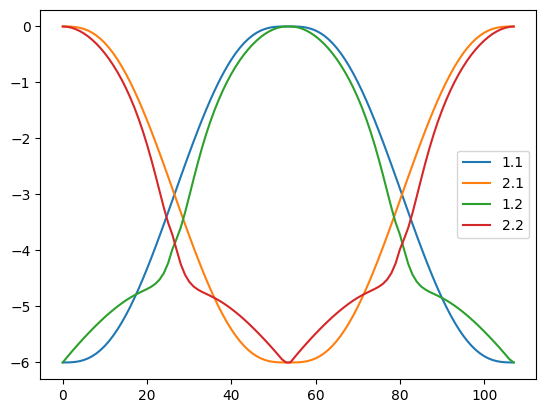

108 108


In [80]:
transport1 = third_order1
transport2 = third_order2

plt.plot(transport1, label = '1.1')
plt.plot(transport2, label = '2.1')
plt.plot(redramp[1], label = '1.2')
plt.plot(redramp[2], label = '2.2')
plt.legend()
plt.show()

print(len(transport1), len(redramp[1]))

In [81]:
time_array = np.asarray(redramp[0], dtype=np.float64)
waveform_1 = np.asarray(transport1, dtype=np.float64)
waveform_2 = np.asarray(transport2, dtype=np.float64)

## Use Case

Waveform 1

In [82]:
# input data:
waveform_size = 1 # not already normalized
time_step = 0.00000038 # DAQ lower limit
wait_time = 0.00003

# waveform data:
waveform = waveform_1
time_array, waveform = FilterSimulation().pre_setup(waveform, waveform_size, wait_time)

# optimization:
best_params, reg_array = Optimize().optimizer(time_array, waveform)
compress = best_params[0]
pad = best_params[1] 
reg = best_params[2]
error = best_params[3]

# setup waveform:
time, original = FilterSimulation().setup(time_array, waveform, compress, pad)

# begin filter simulation:
# -- filtered
filtered = FilterSimulation().convolution(original)
shift_f = np.arange(len(filtered)) * time_step
filtered = FilterSimulation().interpolation(time, shift_f, filtered)

# -- precompensated setup
precompensated = FilterSimulation().precompensation(original, reg, pad)
precompensated = precompensated[:len(original)]
precompensated = FilterSimulation().trimming(original, precompensated, pad)

# -- precompensated filtered
precompensated_filtered = FilterSimulation().convolution(precompensated)
shift_p = np.arange(len(precompensated_filtered)) * time_step
precompensated_filtered = FilterSimulation().interpolation(time, shift_p, precompensated_filtered)

# -- precompensated unfiltered
shift_p_unfiltered = np.arange(len(precompensated)) * time_step
precompensated_unfiltered = FilterSimulation().interpolation(time, shift_p_unfiltered, precompensated)

# -- results:
# compression_grids = Optimize().get_grids(time_array, waveform, best_params)
# Optimize().heatmap(best_params, compression_grids, reg_array)
# Optimize().error_plotter(time, original, precompensated_filtered, best_params) # <-- error checker
# Optimize().tradeoff_plot(time_array, waveform, best_params)
# FilterSimulation().plotter(original, time, filtered, precompensated_unfiltered, precompensated_filtered)
# FilterSimulation().scatter_plot(time, precompensated)
# print(f'There are', len(original),'points total.')

# setup for redramp preparation:
new_time = time
waveform_1_orig = precompensated_filtered
waveform_1_precomp = precompensated_unfiltered

Waveform 2

In [83]:
# waveform data:
waveform = waveform_2
time_array, waveform = FilterSimulation().pre_setup(waveform, waveform_size, wait_time)

# setup waveform:
time, original = FilterSimulation().setup(time_array, waveform, compress, pad)

# begin filter simulation:
# -- filtered
filtered = FilterSimulation().convolution(original)
shift_f = np.arange(len(filtered)) * time_step
filtered = FilterSimulation().interpolation(time, shift_f, filtered)

# -- precompensated setup
precompensated = FilterSimulation().precompensation(original, reg, pad)
precompensated = precompensated[:len(original)]
precompensated = FilterSimulation().trimming(original, precompensated, pad)

# -- precompensated filtered
precompensated_filtered = FilterSimulation().convolution(precompensated)
shift_p = np.arange(len(precompensated_filtered)) * time_step
precompensated_filtered = FilterSimulation().interpolation(time, shift_p, precompensated_filtered)

# -- precompensated unfiltered
shift_p_unfiltered = np.arange(len(precompensated)) * time_step
precompensated_unfiltered = FilterSimulation().interpolation(time, shift_p_unfiltered, precompensated)

# -- results:
# compression_grids = Optimize().get_grids(time_array, waveform, best_params)
# Optimize().heatmap(best_params, compression_grids, reg_array)
# Optimize().error_plotter(time, original, precompensated_filtered, best_params) # <-- error checker
# Optimize().tradeoff_plot(time_array, waveform, best_params)
# FilterSimulation().plotter(original, time, filtered, precompensated_unfiltered, precompensated_filtered)
# # FilterSimulation().scatter_plot(time, precompensated)
# print(f'There are', len(original),'points total.')

# setup for redramp preparation:
new_time = time
waveform_2_orig = precompensated_filtered
waveform_2_precomp = precompensated_unfiltered

### New Redramp:

In [84]:
new_redramp = np.array([new_time, (waveform_1_precomp+0.01)-6, waveform_2_precomp+0.01])

### Plotted Output:

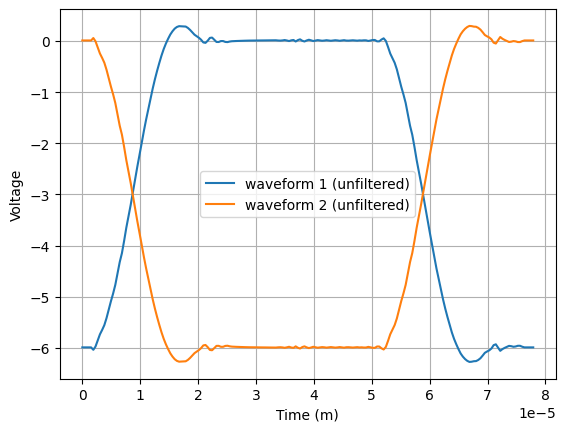

In [95]:
plt.plot(new_redramp[0], new_redramp[1], label = 'waveform 1 (unfiltered)', linestyle = '--')  # <-- must start at 0 (transformed to start at -6 v))
plt.plot(new_redramp[0], new_redramp[2], label = 'waveform 2 (unfiltered)', linestyle = '--')

plt.plot(new_time, waveform_1_orig-6, label = 'waveform 1 (filtered)')
plt.plot(new_time, waveform_2_orig, label = 'waveform 1 (filtered)')

plt.grid(True)
plt.xlabel('Time (m)')
plt.ylabel('Voltage')
plt.legend()
plt.show()

## Excitation Optimization:

### What Causes Excitation?

Excitation is caused by a larger rate of change aka dV/dt value. So, this needs to be minimized. For the original ramp, this is:

The abs min is -768552 the abs max is 776578


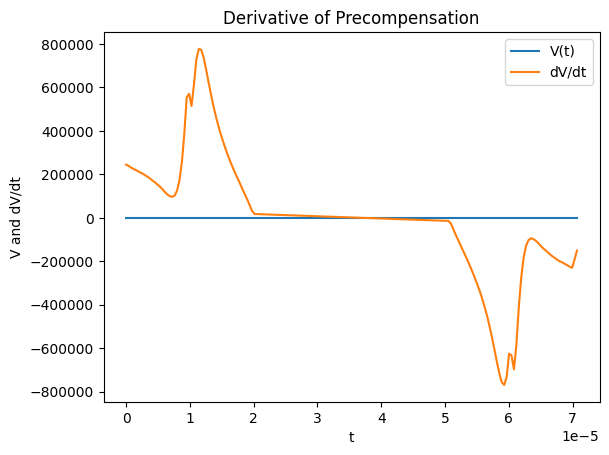

In [86]:
t = redramp[0]
V = redramp[1]

dV_dt = np.gradient(V, t)

diff_min = int(np.min(dV_dt))
diff_max = int(np.max(dV_dt))

print(f'The abs min is', diff_min, 'the abs max is', diff_max)

plt.plot(t, V, label="V(t)")
plt.plot(t, dV_dt, label="dV/dt")
plt.xlabel("t")
plt.ylabel("V and dV/dt")
plt.legend()
plt.title("Derivative of Precompensation")
plt.show()

For the precompensated ramp, worse excitation scales off of larger min/max:

The abs min is -660473 the abs max is 665017


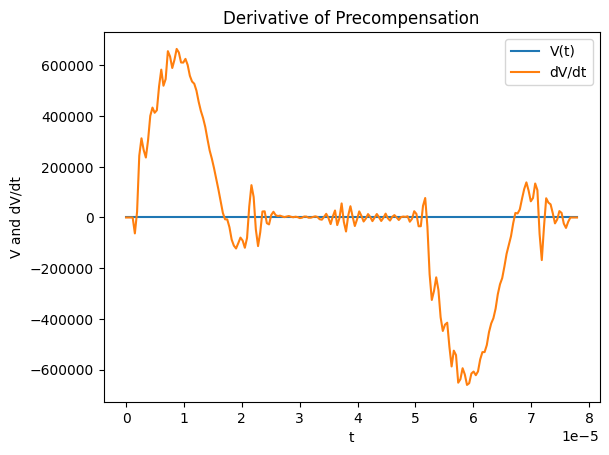

In [87]:
t = new_redramp[0]
V = new_redramp[1]

dV_dt = np.gradient(V, t)

precomp_diff_min = int(np.min(dV_dt))
precomp_diff_max = int(np.max(dV_dt))

print(f'The abs min is', precomp_diff_min, 'the abs max is', precomp_diff_max)

plt.plot(t, V, label="V(t)")
plt.plot(t, dV_dt, label="dV/dt")
plt.xlabel("t")
plt.ylabel("V and dV/dt")
plt.legend()
plt.title("Derivative of Precompensation")
plt.show()

Difference should be as negative as possible (means lower precompensation dV/dt --> lower excitation)

In [88]:
diff_min_abs = diff_min - precomp_diff_min
diff_max_abs = precomp_diff_max - diff_max

print(f'The abs min diff is', diff_min_abs, 'abs max diff is', diff_max_abs)

The abs min diff is -108079 abs max diff is -111561


### Excitation:

energy/hbar_omega: [349.6664394]
-0.0003 -0.000300508444983957


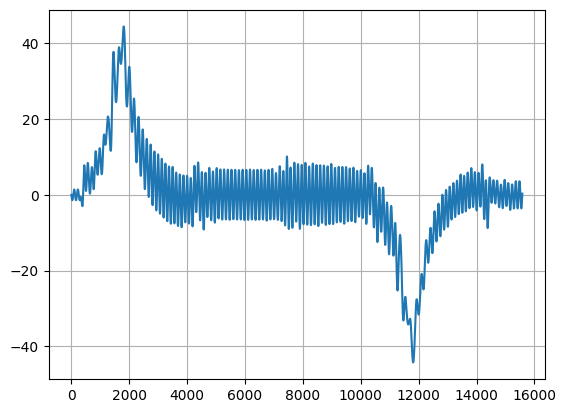

In [89]:
energy, p = Energize().excite(new_redramp)
first_p = p[0,0,0,0]
last_p = p[-1, 0, 0, 0] # <-- end at same position (15 --> 16 --> 15)

print(f'energy/hbar_omega:', energy / hbar_omega)
print(first_p, last_p)

plt.plot(p[:, 0, 1, 0])
plt.grid(True)
plt.show()

### Compare to Original Ramp:

energy/hbar_omega: [75.96217604]
-0.0003 -0.00029990713363558776


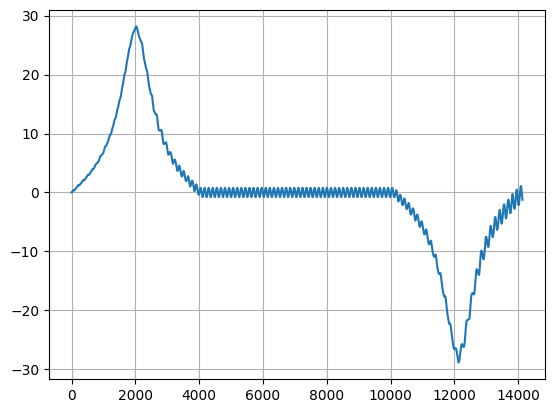

In [90]:
energy, p = Energize().excite(redramp)
first_p = p[0,0,0,0]
last_p = p[-1, 0, 0, 0]

print(f'energy/hbar_omega:', energy / hbar_omega)
print(first_p, last_p)

plt.plot(p[:, 0, 1, 0])
plt.grid(True)
plt.show()

In [91]:
print(get_freq())

Angular Frequency = 2.665366e+06 rad/s   |   f0 = 4.242062e+05 Hz  (0.424 MHz)
2665366.305303277


## Excitation vs Compression

After precompensating waveforms 1 and 2, combine into 3-array redramp: <br> <br>
redramp[0] =  Time Array <br>
redramp[1] =  Waveform 1 <br>
redramp[2] = Waveform 2 <br>

## Builds list of all compression best cases

Define Input Waveform (Redramp):

In [92]:
redramp = np.load('redramp.npy')

time_array = redramp[0].copy()
waveform_1 = redramp[1].copy()
waveform_2 = redramp[2].copy()

Get Best Parameters per Compression:

In [93]:
waveform_size = 1
time_step = 0.00000038
wait_time = 0.00003

waveform = waveform_1
time_array, waveform = FilterSimulation().pre_setup(waveform, waveform_size, wait_time)
best_best_params_abs = Optimize().exc_comp_plotter(time_array, waveform)

lista = [[],[],[]]

for i in best_best_params_abs:
    lista[0].append(i[0][0]) # compressions
    lista[1].append(i[0][1]) # padding
    lista[2].append(i[0][2]) # regularization

print(lista)

[[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11], [10, 10, 14, 12, 15, 14, 19, 15, 17, 26, 14], [0.0002, 0.0002, 1e-06, 3e-06, 4.9999999999999996e-06, 4e-06, 4.9999999999999996e-06, 3e-06, 1e-05, 1e-06, 3e-06]]


Run for all Cases:

In [94]:
waveform_size = 1
time_step = 0.00000038
wait_time = 0.00003
all_energies = []
all_p = []
strength = 5e-9

# precompensation:
for i in range(0, lista[0][-1]):
    redramp_precompensated = np.array([[], [], []])

    compress = lista[0][i]
    pad = lista[1][i] 
    reg = lista[2][i]
    
    # waveform 1:
    time, original = FilterSimulation().setup(time_array.copy(), waveform.copy(), compress, pad)
    precompensated = FilterSimulation().precompensation(original, reg, pad)    
    precompensated = precompensated[:len(original)]    
    precompensated = FilterSimulation().trimming(original, precompensated, pad)
    shift_p_unfiltered = np.arange(len(precompensated)) * time_step
    precompensated_unfiltered = FilterSimulation().interpolation(time, shift_p_unfiltered, precompensated)

    new_time = time
    waveform_1_precomp = precompensated_unfiltered

    # waveform 2:
    waveform = waveform_2
    time_array, waveform = FilterSimulation().pre_setup(waveform, waveform_size, wait_time)

    time, original = FilterSimulation().setup(time_array, waveform, compress, pad)
    precompensated = FilterSimulation().precompensation(original, reg, pad)    
    precompensated = precompensated[:len(original)]    
    precompensated = FilterSimulation().trimming(original, precompensated, pad)
    precompensated_unfiltered = FilterSimulation().interpolation(time, shift_p_unfiltered, precompensated)

    waveform_2_precomp = precompensated_unfiltered

    redramp_precompensated = np.array([new_time, (waveform_1_precomp+0.01)-6, waveform_2_precomp+0.01])

    energy, p = Energize().excite(redramp_precompensated, strength)
    all_p.append(p)
    all_energies.append(energy)

    print(f'run', i+1, 'energy/hbar', energy / hbar_omega)

TypeError: Energize.excite() takes 2 positional arguments but 3 were given

In [ ]:
first_p = p[0,0,0,0]
last_p = p[-1, 0, 0, 0]
print(first_p, last_p)

-0.0003 nan


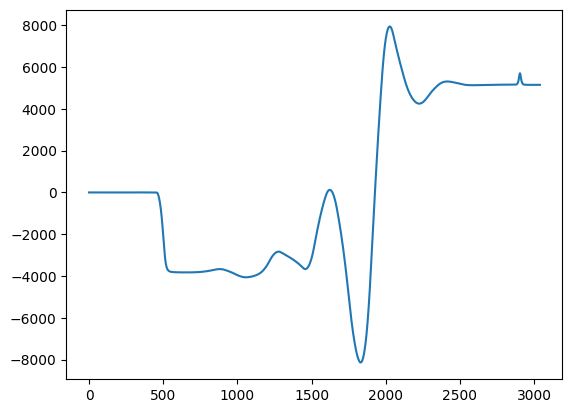

In [ ]:
plt.plot(p[:, 0, 1, 0])

In [ ]:
waveform_size = 1
time_step = 0.00000038
wait_time = 0.00003
all_energies = []

# precompensation:
for i in range(0, lista[0][-1]):
    redramp_precompensated = np.array([[], [], []])

    compress = lista[0][i]
    pad = lista[1][i] 
    reg = lista[2][i]
    
    # waveform 1:
    time, original = FilterSimulation().setup(time_array.copy(), waveform.copy(), compress, pad)
    precompensated = FilterSimulation().precompensation(original, reg, pad)    
    precompensated = precompensated[:len(original)]    
    precompensated = FilterSimulation().trimming(original, precompensated, pad)
    shift_p_unfiltered = np.arange(len(precompensated)) * time_step
    precompensated_unfiltered = FilterSimulation().interpolation(time, shift_p_unfiltered, precompensated)

    new_time = time
    waveform_1_precomp = precompensated_unfiltered

    # waveform 2:
    waveform = waveform_2
    time_array, waveform = FilterSimulation().pre_setup(waveform, waveform_size, wait_time)

    time, original = FilterSimulation().setup(time_array, waveform, compress, pad)
    precompensated = FilterSimulation().precompensation(original, reg, pad)    
    precompensated = precompensated[:len(original)]    
    precompensated = FilterSimulation().trimming(original, precompensated, pad)
    precompensated_unfiltered = FilterSimulation().interpolation(time, shift_p_unfiltered, precompensated)

    waveform_2_precomp = precompensated_unfiltered

    redramp_precompensated = np.array([new_time, (waveform_1_precomp+0.01)-6, waveform_2_precomp+0.01])
    energy = Energize().excite(redramp_precompensated)
    all_energies.append(energy)

    print(f'run', i+1, 'energy/hbar', energy / hbar_omega)

TypeError: unsupported operand type(s) for /: 'tuple' and 'float'

In [ ]:
all_angular_frequencies = []
for i in range(0, len(all_energies)-2):
    all_angular_frequencies.append(all_energies[i] / hbar_omega)
    
plt.plot(all_angular_frequencies, marker = 'o')
plt.ylabel('energy / hbar_omega')
plt.xlabel('compression')
plt.grid(True)
plt.show()

Ion Position after Propegation:

In [ ]:
redtrap = red_system(trap)
redtrap.setIons(np.array([[[-300.0e-6],[0],[0]],], dtype=np.float64))
voltage = np.zeros((16, 1))
voltage[15, 0] = -1
redtrap.volt = voltage
print(minimize(lambda t: redtrap.getPot(t, 0), 300e-6))

x = np.linspace(-1e-3, 1e-3, 1000)
redtrap.getPot(np.array([100e-6]), 0)

pot = redtrap.getPot(x, 0)         # potential array
idx_min = np.argmin(pot)           # index of minimum value
x_min = x[idx_min]                 # x-value at minimum
pot_min = pot[idx_min]              # minimum potential value

print('---------------')
print("x_min:", x_min)
print("y_min:", pot_min)

plt.figure(figsize = (12, 7))
plt.plot(x, redtrap.getPot(x, 0))
plt.plot(x_min, pot_min, 'ro')
plt.text(x_min, pot_min, f'({x_min}, {pot_min})', ha='left', va='bottom')
plt.show()

### Plot result <a id="restheory"></a>

Original:

In [ ]:
redramp = np.load('redramp.npy')

plt.plot(redramp[0], redramp[1])
plt.show()

In [ ]:
result = []
redramp = np.load('redramp.npy')

def run(i, j):
    transport = np.zeros((17, 108), dtype=np.float64)
    transport[[0, 15, 16], :54] = redramp[:, :54]
    transport[0, :54] *= j

    # vary the dwelltime from 0 .. 1us
    transport[0, 54:] = transport[0, :54] + i + transport[0, 53]
    transport[15, 54:] = transport[16, :54]
    transport[16, 54:] = transport[15, :54]

    # set Ion at -300um e.g. the center of segment 15 of the redtrap; (trap segments are 200um wide each)
    redtrap = red_system(trap)  
    redtrap.setIons(np.array([[[-300.0e-6],[0],[0]],], dtype=np.float64))

    # propagates / simulates the ion trajectory and give back: t--timesteps, p--position
    #        ppoints[:, 0, 0, 0]
    #                |  |  |  |
    #                |  |  |  > dimension x (or general 1st dim)
    #                |  |  > 0 is position, 
    #                |  |    1 velocity, 2 acceleration
    #                |  > choose ion #0
    #                > all timesteps
    t, p = redtrap.propagate(transport, transport[0, -1], 5e-9)

    volt = redtrap.getPot(p[-1, :, 0, 0], -1)
    volt0 = redtrap.getPot(p[0, :, 0, 0], 0)
    
    # masse u in eV
    c = 299792458# m/s
    massunit = 931.49410242e6/c**2 # eV * s^2 / m^2
    mCa40 = 39.962590866 * massunit
    
    # energy in eV
    energy = volt-volt0 + 0.5 * mCa40 * p[-1, 0, 1, 0]**2

    return [i, j, energy[0]]


for i in tqdm(np.linspace(0, 1e-6, 32)):
    for j in np.linspace(1, 1.06, 30):
        result.append(run(i, j))

In [ ]:
init_pos = p[0, 0, 0, :]
final_x_pos = p[-1, 0, 0, 0]
print(init_pos, final_x_pos)

In [ ]:
r = np.array(result)
fig, ax = plt.subplots(figsize=(12,8))
pc = ax.pcolormesh(r[:, 0].reshape((-1, 30))*1e6, 
                   r[:, 1].reshape((-1, 30))*20, 
                   r[:, 2].reshape((-1, 30))/hbar_omega, cmap='coolwarm')

cbar = fig.colorbar(pc)
cbar.set_label(r'n [$\hbar\omega$]')
ax.set_title('Ion excitation')
ax.set_xlabel("dwelltime [us]")
ax.set_ylabel("transporttime [us]")

Precompensated:

In [ ]:
plt.plot(redramp_precompensated[0], redramp_precompensated[1])
plt.show()

In [ ]:
result = []
redramp = redramp_precompensated

def run(i, j):
    transport = np.zeros((17, 108), dtype=np.float64)
    transport[[0, 15, 16], :54] = redramp[:, :54]
    transport[0, :54] *= j

    # vary the dwelltime from 0 .. 1us
    transport[0, 54:] = transport[0, :54] + i + transport[0, 53]
    transport[15, 54:] = transport[16, :54]
    transport[16, 54:] = transport[15, :54]

    # set Ion at -300um e.g. the center of segment 15 of the redtrap; (trap segments are 200um wide each)
    redtrap = red_system(trap)  
    redtrap.setIons(np.array([[[-300.0e-6],[0],[0]],], dtype=np.float64))

    # propagates / simulates the ion trajectory and give back: t--timesteps, p--position
    #        ppoints[:, 0, 0, 0]
    #                |  |  |  |
    #                |  |  |  > dimension x (or general 1st dim)
    #                |  |  > 0 is position, 
    #                |  |    1 velocity, 2 acceleration
    #                |  > choose ion #0
    #                > all timesteps
    t, p = redtrap.propagate(transport, transport[0, -1], 3e-9)

    volt = redtrap.getPot(p[-1, :, 0, 0], -1)
    volt0 = redtrap.getPot(p[0, :, 0, 0], 0)
    
    # masse u in eV
    c = 299792458# m/s
    massunit = 931.49410242e6/c**2 # eV * s^2 / m^2
    mCa40 = 39.962590866 * massunit
    
    # energy in eV
    energy = volt-volt0 + 0.5 * mCa40 * p[-1, 0, 1, 0]**2

    return [i, j, energy[0]]

for i in tqdm(np.linspace(0, 1e-6, 32)):
    for j in np.linspace(1, 1.06, 30):
        result.append(run(i, j))

In [ ]:
r = np.array(result)
fig, ax = plt.subplots(figsize=(12,8))
pc = ax.pcolormesh(r[:, 0].reshape((-1, 30))*1e6, 
                   r[:, 1].reshape((-1, 30))*20, 
                   r[:, 2].reshape((-1, 30))/hbar_omega, cmap='coolwarm')

cbar = fig.colorbar(pc)
cbar.set_label(r'n [$\hbar\omega$]')
ax.set_title('Ion excitation')
ax.set_xlabel("dwelltime [us]")
ax.set_ylabel("transporttime [us]")

In [ ]:
print("Initial potential:", volt0)
print("Final potential:", volt)
print("Potential difference:", volt - volt0)
print("Kinetic energy:", 0.5 * mCa40 * p[-1, 0, 1, 0]**2)

In [ ]:
r = np.array(result)
fig, ax = plt.subplots(figsize=(12,8))
pc = ax.pcolormesh(r[:, 0].reshape((-1, 30))*1e6, 
                   r[:, 1].reshape((-1, 30))*20, 
                   r[:, 2].reshape((-1, 30))/hbar_omega, cmap='coolwarm')

cbar = fig.colorbar(pc)
cbar.set_label(r'n [$\hbar\omega$]')
ax.set_title('Ion excitation')
ax.set_xlabel("dwelltime [us]")
ax.set_ylabel("transporttime [us]")